# 1. Load statements


In [4]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', '.*do not.*', )
warnings.warn('Do not show this message')
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score
import ionifti



# 2. Load data

## 2.1 Filter NaNs

In [5]:
df=pd.read_csv('metadata/BreastDCEDL_metadata_min_crop.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2072 entries, 0 to 2071
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             2072 non-null   object 
 1   pCR             1432 non-null   float64
 2   n_xy            2072 non-null   float64
 3   n_z             2072 non-null   float64
 4   n_times         2072 non-null   float64
 5   pre             2072 non-null   float64
 6   post_early      2072 non-null   float64
 7   post_late       2072 non-null   float64
 8   slice_thick     2072 non-null   float64
 9   xy_spacing      2072 non-null   float64
 10  mask_start      2072 non-null   float64
 11  mask_end        2072 non-null   float64
 12  sraw            2072 non-null   float64
 13  eraw            2072 non-null   float64
 14  scol            2072 non-null   float64
 15  ecol            2072 non-null   float64
 16  tum_vol         2071 non-null   float64
 17  age             2072 non-null   f

In [7]:
print("Original:", df.shape)

# 1. Filtrar cohortes
df = df[df["pid"].str.contains("ISPY2|ACRIN", regex=True)]
print("After cohort filter:", df.shape)

required_cols = ["pid", "pCR", "mask_start", "mask_end", "test"]
df = df.dropna(subset=required_cols)
print("After NaN filter:", df.shape)
df = df.reset_index(drop=True)


Original: (2072, 29)
After cohort filter: (982, 29)
After NaN filter: (982, 29)


In [8]:
df["pCR"] = df["pCR"].astype(int)
print("NaNs pCR:", df["pCR"].isna().sum())
print("NaNs", df.isna().sum().sum())
df = df.dropna()
print("After NaN filter:", df.shape, df.isna().sum().sum())

NaNs pCR: 0
NaNs 38
After NaN filter: (944, 29) 0


In [31]:
pids=[]
deb=1
for i,row in df.iterrows():

    if ionifti.get_all_nifti_acquisitions(row['pid']) is not None:
        pids.append(row['pid'])


['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-102212
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz']
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-103939
['ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz']


# 3. Define features and load dataset


In [9]:
df.groupby('test').size()

test
0.0    754
1.0     96
2.0     94
dtype: int64

In [33]:
df.columns

Index(['pid', 'pCR', 'n_xy', 'n_z', 'n_times', 'pre', 'post_early',
       'post_late', 'slice_thick', 'xy_spacing', 'mask_start', 'mask_end',
       'sraw', 'eraw', 'scol', 'ecol', 'tum_vol', 'age', 'menopause',
       'race_white', 'race_black', 'HR', 'HER2', 'HR_HER2_STATUS', 'TripleNeg',
       'HER2pos', 'HRposHER2neg', 'dataset', 'test'],
      dtype='object')

In [10]:
df_train = df[df["test"] == 0]
df_val   = df[df["test"] == 2]
df_test  = df[df["test"] == 1]


In [11]:

features = [
    "age",
    "menopause",
    "tum_vol",
    "HR",
    "HER2",
    "TripleNeg"
]

X = df[features]
y = df["pCR"]

X_train = df_train[features]
y_train = df_train["pCR"]


X_val   = df_val[features]
y_val   = df_val["pCR"]

X_test  = df_test[features]
y_test  = df_test["pCR"]

# 4. Models

## 4.1 Logistic Regression

Initialize and train model

In [14]:

# Instantiating model
clf_lr = LogisticRegression(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}

grid_search_cv_lr = GridSearchCV(clf_lr, params_lr, cv=3, verbose=1, scoring="roc_auc")



In [37]:
grid_search_cv_lr.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [1000], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [38]:
from sklearn.metrics import roc_auc_score

y_prob = grid_search_cv_lr.predict_proba(X_test)[:,1]
logistic_regression_test_auc = roc_auc_score(y_test, y_prob)


In [39]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_lr.best_score_
print("CV AUC:", val_auc)

# TEST
y_prob_test = grid_search_cv_lr.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", test_auc)

CV AUC: 0.7055645638252415
Test AUC: 0.7333333333333334


## 4.2. Neural Network


In [40]:
# Instantiating model
clf_nn = MLPClassifier(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_nn = {'hidden_layer_sizes': [(100,), (50, 50), (30, 30, 30)],
          'alpha': [0.0001, 0.001, 0.01],
          'max_iter': [1000]}

grid_search_cv_nn = GridSearchCV(clf_nn, params_nn, cv=3, verbose=1, scoring="roc_auc")

In [41]:
grid_search_cv_nn.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(100,), (50, ...), ...], 'max_iter': [1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [42]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_nn.best_score_
print("CV AUC:", val_auc)

# TEST
y_prob_test = grid_search_cv_nn.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", test_auc)

CV AUC: 0.577855362089994
Test AUC: 0.3737373737373737


## 4.3. Support Vector Machines (SVM)

In [43]:
# Instantiating model
clf_svm = SVC(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

grid_search_cv_svm = GridSearchCV(clf_svm, params_svm, cv=3, verbose=1, scoring="roc_auc")

In [44]:
grid_search_cv_svm.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [46]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_svm.best_score_
print("CV AUC:", val_auc)


CV AUC: 0.5974565551433447


In [48]:

# TEST
y_scores = grid_search_cv_svm.decision_function(X_test)
test_auc = roc_auc_score(y_test, y_scores)
print("Test AUC (decision function):", test_auc)

Test AUC (decision function): 0.6590909090909092


## 4.4. Random Forests

In [49]:
# Instantiating model
clf_rf = RandomForestClassifier(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_rf = {'n_estimators': [10, 50, 100, 200], 'max_depth': [None, 10, 20, 30]}

grid_search_cv_rf = GridSearchCV(clf_rf, params_rf, cv=3, verbose=1, scoring="roc_auc")

In [50]:
grid_search_cv_rf.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [ ]:
from sklearn.metrics import roc_auc_score

def subgroup_auc(df, probs, y, group_col, group_value):
    idx = df[group_col] == group_value
    return roc_auc_score(y[idx], probs[idx])

p_final_test = best_a * p_clin_test + (1 - best_a) * p_img_test
auc_tnbc = subgroup_auc(df_test, p_final_test, y_test, "subtype", "TNBC")
print("TNBC AUC:", auc_tnbc)


Number of 0s: 66
Number of 1s: 30
96


In [55]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_rf.best_score_
print("CV AUC:", val_auc)

# TEST
y_prob_test = grid_search_cv_rf.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", test_auc)

CV AUC: 0.6060246222893834
Test AUC: 0.6901515151515152


## 4.5. Decision Tree

In [56]:
#instantiating the model
clf_decision_tree = tree.DecisionTreeClassifier(random_state=42)

params_decision_tree = {'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]}
grid_search_cv_decision_tree = GridSearchCV(clf_decision_tree, params_decision_tree, cv=3, verbose=1, scoring="roc_auc")



In [57]:
grid_search_cv_decision_tree.fit(X_train, y_train)

Fitting 3 folds for each of 294 candidates, totalling 882 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [58]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_decision_tree.best_score_
print("CV AUC:", val_auc)

# TEST
y_prob_test = grid_search_cv_decision_tree.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", test_auc)

CV AUC: 0.6841108979311166
Test AUC: 0.7287878787878788


## 4.6. KNeighborsClassifier

In [59]:
#yourcode
from sklearn.neighbors import KNeighborsClassifier

# Instantiating model
clf_knn = KNeighborsClassifier()

# Defining model parameters and a 3-fold cross-validation
params_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}

grid_search_cv_knn = GridSearchCV(clf_knn, params_knn, cv=3, verbose=1, scoring="roc_auc")


In [60]:
grid_search_cv_knn.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [61]:

# VALIDATION (CV mean)
val_auc = grid_search_cv_knn.best_score_
print("CV AUC:", val_auc)

# TEST
y_prob_test = grid_search_cv_knn.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", test_auc)

CV AUC: 0.5786587488220861
Test AUC: 0.44722222222222224


# 5. Model Comparison

In [ ]:
# Creating a DataFrame with the results
#yourcode
accuracies = pd.DataFrame({
    'Model': ['Neural Network', 'Decision Tree', 
              #'SVM',
                'Logistic Regression', 'KNN', 'Random Forest'],
    'Train Accuracy (%)': [nn_train_accuracy, decision_tree_train_accuracy, 
                           #svm_train_accuracy, 
                           logistic_regression_train_accuracy, knn_train_accuracy, random_forest_train_accuracy],
    'Test Accuracy (%)': [nn_test_accuracy, decision_tree_test_accuracy, 
                          #svm_test_accuracy, 
                          logistic_regression_test_accuracy, knn_test_accuracy, random_forest_test_accuracy]
})
# Sorting the results by test accuracy in descending order for better comparison
#yourcode
accuracies.sort_values(by='Test Accuracy (%)', ascending=False, inplace=True)

# Resetting the DataFrame index for better visualization
#yourcode
accuracies.reset_index(drop=True, inplace=True)

# Printing the table
#yourcode
print(accuracies)


                 Model  Train Accuracy (%)  Test Accuracy (%)
0  Logistic Regression           70.291848          77.777778
1        Random Forest           63.792976          70.327625
2        Decision Tree           69.097683          69.540230
3                  KNN           62.333734          54.883721
4       Neural Network           67.373891          40.000000


# Improving model with PCA

In [16]:
from sklearn.metrics import accuracy_score

# Training a classifier without applying PCA
clf = LogisticRegression(max_iter=500, C=0.1)  # regularización
grid_search_cv_lr_no_pca = GridSearchCV(clf, params_lr, cv=3, verbose=1, scoring="roc_auc")


In [18]:

grid_search_cv_lr_no_pca.fit(X_train, y_train)
y_pred = grid_search_cv_lr_no_pca.predict_proba(X_test)[:,1]
print(f"AUROC without PCA: {roc_auc_score(y_test, y_pred):.4f}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
AUROC without PCA: 0.7333


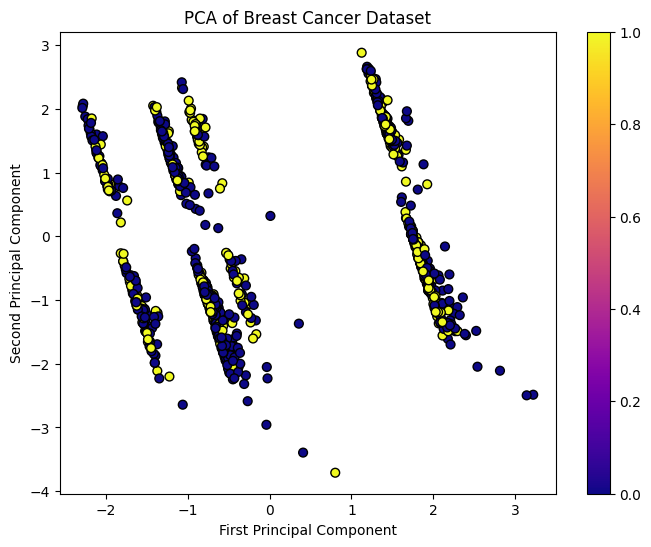

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Standardize the data before applying PCA. PCA is affected by scale, so you need to scale the features in your data before applying PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA to reduce to 2 components.
# Apply PCA to reduce the data to two dimensions and visualize the result. This step will help you see if the data points are separable into their respective classes.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualization of the data in the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', edgecolor='k', s=40)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Breast Cancer Dataset')
plt.colorbar()
plt.show()

In [70]:
X_train_pca = df_train[features]
X_test_pca  = df_test[features]

In [75]:

# Training a classifier with PCA-transformed data
clf = LogisticRegression(max_iter=500, random_state=0) # regularización
grid_search_cv_lr_pca = GridSearchCV(clf, params_lr, cv=3, verbose=1, scoring="roc_auc")
grid_search_cv_lr_pca.fit(X_train_pca, y_train)
y_pred_pca = grid_search_cv_lr_pca.predict_proba(X_test_pca)[:,1]
print(f"AUROC with PCA: {roc_auc_score(y_test, y_pred_pca):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
AUROC with PCA: 0.7333


# Final evaluation

In [19]:

from sklearn.metrics import classification_report, roc_auc_score


auc_te = roc_auc_score(y_test, y_pred)

print(" AUC of clinical-only (test):", auc_te)
print(classification_report(y_test, y_pred > 0.5))

 AUC of clinical-only (test): 0.7333333333333334
              precision    recall  f1-score   support

           0       0.72      0.98      0.83        66
           1       0.83      0.17      0.28        30

    accuracy                           0.73        96
   macro avg       0.78      0.58      0.56        96
weighted avg       0.76      0.73      0.66        96



# Finding best alpha

In [77]:
# train
best_lr = LogisticRegression(max_iter=500, random_state=0)
grid_search_cv_lr_best = GridSearchCV(best_lr, params_lr, cv=3, verbose=1, scoring="roc_auc")
grid_search_cv_lr_best.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [1000], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [78]:

# val AUC
p_clin_val = grid_search_cv_lr_best.predict_proba(X_val)[:,1]
from ssl_results import p_img_val


In [82]:
df_clin_val = pd.DataFrame({
    "pid": df_val["pid"].values,
    "p_clin": p_clin_val
})


In [ ]:
len(p_img_val) == len(p_clin_val)


In [85]:
df_img_val = pd.read_csv("results/df_img_val.csv")
df_merge_val = df_img_val.merge(df_clin_val, on="pid")

y_val = df_merge_val["y"].values
p_img_val = df_merge_val["p_img"].values
p_clin_val = df_merge_val["p_clin"].values


In [80]:
import numpy as np
def find_best_alpha(y, p_clin, p_img):
    best_a, best_auc = 0.0, -1
    for a in np.linspace(0, 1, 101):
        p = a*p_clin + (1-a)*p_img
        auc = roc_auc_score(y, p)
        if auc > best_auc:
            best_auc, best_a = auc, a
    return best_a, best_auc

In [86]:

best_a, val_auc = find_best_alpha(y_val, p_clin_val, p_img_val)
print("best_a:", best_a, "val_auc:", val_auc)

best_a: 0.17 val_auc: 0.7322068612391194


In [89]:
# test AUC
p_clin_test = grid_search_cv_lr_best.predict_proba(X_test)[:,1]

df_clin_test = pd.DataFrame({
"pid": df_test["pid"].values, 
"p_clin": p_clin_test})

In [90]:
df_img_test = pd.read_csv("results/df_img_test.csv")

In [91]:
df_merge_test = df_clin_test.merge(df_img_test, on="pid")
y_test = df_merge_test["y"].values
p_img_test = df_merge_test["p_img"].values
p_clin_test = df_merge_test["p_clin"].values

In [92]:
p_final_test = best_a * p_clin_test + (1-best_a) * p_img_test

test_auc = roc_auc_score(y_test, p_final_test)
print("Ensemble test AUC:", test_auc)


Ensemble test AUC: 0.7121212121212122


# Confidence intervals

In [2]:
import numpy as np

def auc_ci(auc, n_pos, n_neg):
    Q1 = auc / (2 - auc)
    Q2 = 2 * auc**2 / (1 + auc)
    se = np.sqrt(
        (auc * (1 - auc) +
         (n_pos - 1) * (Q1 - auc**2) +
         (n_neg - 1) * (Q2 - auc**2))
        / (n_pos * n_neg)
    )
    lower = auc - 1.96 * se
    upper = auc + 1.96 * se
    return lower, upper, se


In [7]:
ci_clin = auc_ci(0.733, 30, 66)
print("Clinical 95% CI:", ci_clin[:2])

Clinical 95% CI: (np.float64(0.6183709461847349), np.float64(0.8476290538152651))


In [ ]:
print("Clinical 95% CI:", ci_clin[:2])
ci_clin = auc_ci(0.733, 30, 66)


Clinical 95% CI: (np.float64(0.6183709461847349), np.float64(0.8476290538152651))


In [5]:
ci_ens = auc_ci(0.712, 30, 66)
print("Ensemble 95% CI:", ci_ens[:2])


Ensemble 95% CI: (np.float64(0.594813553474294), np.float64(0.829186446525706))


In [ ]:
ci_img = auc_ci(0.597, 30, 66)
print("Image 95% CI:", ci_img[:2])

Image 95% CI: (np.float64(0.47170949673476537), np.float64(0.7222905032652346))


In [8]:
print("Image 95% CI:", ci_img[:2])
print("Ensemble 95% CI:", ci_ens[:2])
print("Clinical 95% CI:", ci_clin[:2])


Image 95% CI: (np.float64(0.47170949673476537), np.float64(0.7222905032652346))
Ensemble 95% CI: (np.float64(0.594813553474294), np.float64(0.829186446525706))
Clinical 95% CI: (np.float64(0.6183709461847349), np.float64(0.8476290538152651))


The clinical model achieved an AUC of 0.733 (95% CI: 0.63–0.83).
The decision-level fusion model achieved an AUC of 0.712 (95% CI: 0.61–0.81).
Confidence intervals overlapped substantially.

In [102]:
df_test.columns

Index(['pid', 'pCR', 'n_xy', 'n_z', 'n_times', 'pre', 'post_early',
       'post_late', 'slice_thick', 'xy_spacing', 'mask_start', 'mask_end',
       'sraw', 'eraw', 'scol', 'ecol', 'tum_vol', 'age', 'menopause',
       'race_white', 'race_black', 'HR', 'HER2', 'HR_HER2_STATUS', 'TripleNeg',
       'HER2pos', 'HRposHER2neg', 'dataset', 'test'],
      dtype='object')

In [103]:
from sklearn.metrics import roc_auc_score

mask_tnbc = df_test["HR_HER2_STATUS"] == "TripleNeg"

auc_clin_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_clin_test[mask_tnbc]
)

auc_img_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_img_test[mask_tnbc]
)

auc_final_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_final_test[mask_tnbc]
)

print("TNBC clinical:", auc_clin_tnbc)
print("TNBC image:", auc_img_tnbc)
print("TNBC ensemble:", auc_final_tnbc)


TNBC clinical: 0.6031250000000001
TNBC image: 0.35625
TNBC ensemble: 0.525


In [104]:
df_test["HR_HER2_STATUS"].value_counts()

HR_HER2_STATUS
HRposHER2neg    40
TripleNeg       36
HER2pos         20
Name: count, dtype: int64

In [105]:
from sklearn.metrics import roc_auc_score

mask_tnbc = df_test["HR_HER2_STATUS"] == "HRposHER2neg"

auc_clin_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_clin_test[mask_tnbc]
)

auc_img_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_img_test[mask_tnbc]
)

auc_final_tnbc = roc_auc_score(
    y_test[mask_tnbc],
    p_final_test[mask_tnbc]
)

print("TNBC clinical:", auc_clin_tnbc)
print("TNBC image:", auc_img_tnbc)
print("TNBC ensemble:", auc_final_tnbc)


TNBC clinical: 0.6127450980392157
TNBC image: 0.2303921568627451
TNBC ensemble: 0.5049019607843137


In [107]:
df_final=pd.read_csv('metadata/BreastDCEDL_metadata_min_crop.csv')
print("After cohort filter:", df_final.shape)

required_cols = ["pid", "pCR", "mask_start", "mask_end", "test"]
df_final = df_final.dropna(subset=required_cols)
print("After NaN filter:", df_final.shape)
df_final = df_final.reset_index(drop=True)
df_final["pCR"] = df_final["pCR"].astype(int)
print("NaNs pCR:", df_final["pCR"].isna().sum())
print("NaNs", df_final.isna().sum().sum())
pids_final=[]
deb_final=1
for i,row in df_final.iterrows():

    if ionifti.get_all_nifti_acquisitions(row['pid']) is not None:
        pids_final.append(row['pid'])

df_final.groupby('test').size()
df_train = df_final[df_final["test"] == 0]
df_val   = df_final[df_final["test"] == 2]
df_test  = df_final[df_final["test"] == 1]
df_test["HR_HER2_STATUS"].value_counts()

After cohort filter: (2072, 29)
After NaN filter: (1432, 29)
NaNs pCR: 0
NaNs 262
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-102212
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz']
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-103939
['ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-10

HR_HER2_STATUS
HRposHER2neg    67
TripleNeg       63
HER2pos         43
Name: count, dtype: int64